In [4]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv("stroke_dataset.csv")

In [6]:
data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["gender"] = le.fit_transform(data["gender"])

In [7]:

features = ["age","gender","high_blood_pressure","irregular_heartbeat","shortness_of_breath","chest_pain"
           ,"fatigue_weakness","dizziness","snoring_sleep_apnea","swelling_edema","stroke_risk_percentage"]
data = data[features]

In [8]:
data.columns

Index(['age', 'gender', 'high_blood_pressure', 'irregular_heartbeat',
       'shortness_of_breath', 'chest_pain', 'fatigue_weakness', 'dizziness',
       'snoring_sleep_apnea', 'swelling_edema', 'stroke_risk_percentage'],
      dtype='object')

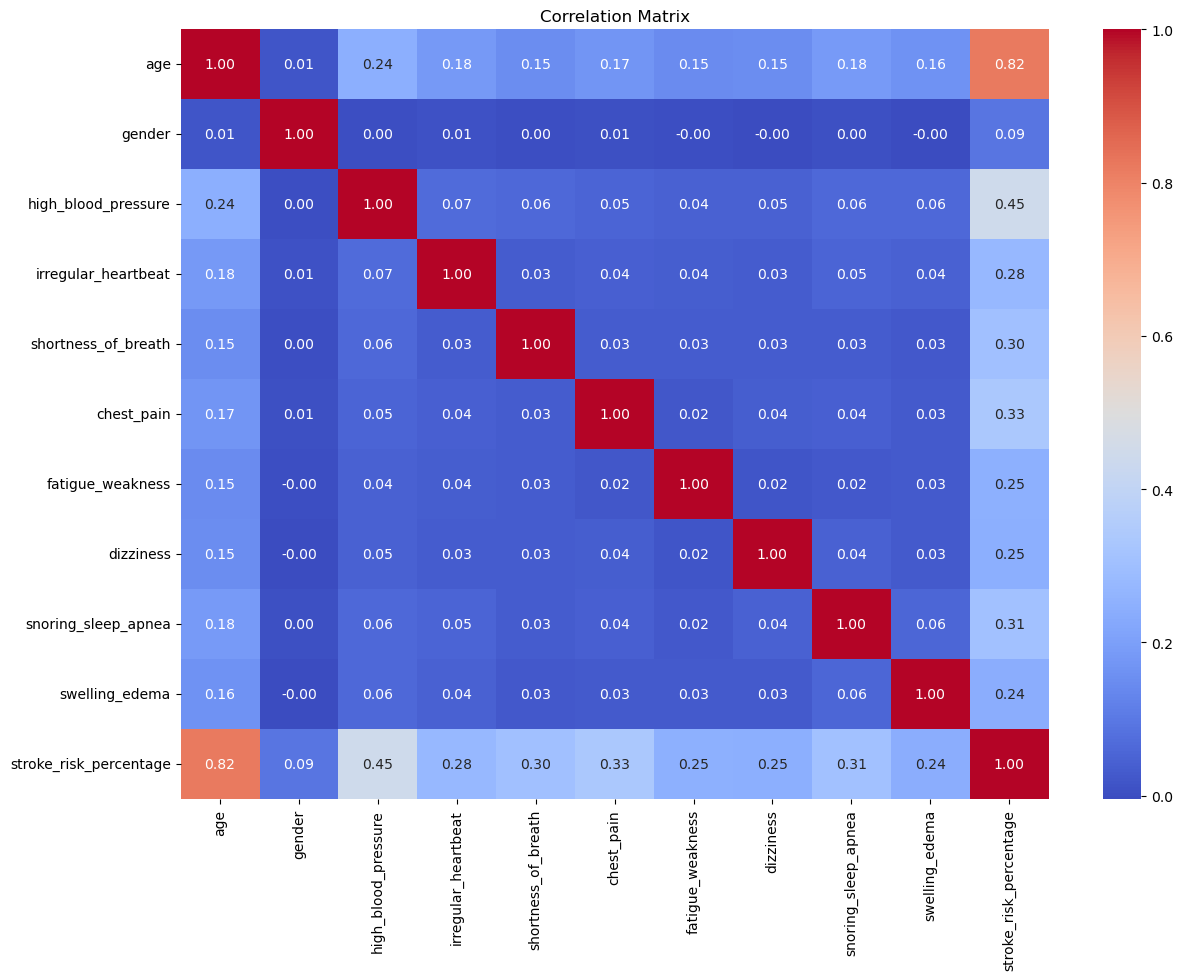

In [53]:
# correlation heatmap 
numeric_df = data.select_dtypes(include = np.number)
plt.figure(figsize =(14,10))
sns.heatmap(
    numeric_df.corr(),
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [9]:
X = data.drop("stroke_risk_percentage",axis = 1)
Y= data["stroke_risk_percentage"]

In [10]:
X_train , X_test,Y_train,Y_test =train_test_split(
    X,Y,test_size = 0.28,random_state = 42
)

In [11]:
Y.head()

0     33.3
1    100.0
2    100.0
3     44.5
4     84.8
Name: stroke_risk_percentage, dtype: float64

In [12]:
from sklearn.ensemble import RandomForestRegressor
model1 = RandomForestRegressor(n_estimators=100, criterion='squared_error', max_depth=None, min_samples_split=2,
                                min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0,
                                bootstrap=True, oob_score=False, n_jobs=None,
                                random_state=None, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

In [13]:
model1.fit(X_train ,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
#! pip install xgboost
from xgboost import XGBRegressor
model2 = XGBRegressor(
    n_estimators = 100 ,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42,
    n_jobs = -1,
    subsample= 0.8,
    colsample_bytree = 0.8
    
)

In [16]:
model2.fit(X_train,Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



mae = mean_absolute_error(Y_test, y_pred1)
mse = mean_squared_error(Y_test, y_pred1)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred1)

print(" model 1 MAE:", mae)
print("model 1 RMSE:", rmse)
print("model 1 R²:", r2)



mae = mean_absolute_error(Y_test, y_pred2)
mse = mean_squared_error(Y_test, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred2)

print(" model 2 MAE:", mae)
print("model 2 RMSE:", rmse)
print("model 2 R²:", r2)

 model 1 MAE: 5.991570520641925
model 1 RMSE: 7.849125144444398
model 1 R²: 0.9306007953932843
 model 2 MAE: 5.975202094232679
model 2 RMSE: 7.5380067287149375
model 2 R²: 0.9359933602940331


In [19]:
# Choosing model2 due to higher r2 value 
import joblib 
joblib.dump(model2 , "stroke_model.pkl")

['stroke_model.pkl']